<a href="https://colab.research.google.com/github/mohamad0-assaad/AI-Model/blob/Student-Ai/Copy_of_AI_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn pandas numpy seaborn joblib matplotlib

# Install Libraries

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

# AI Student Learning Assistant

This project trains machine learning models to:

1. Predict if a student will fail a subject
2. Recommend topics to study
3. Suggest study strategies

The models are trained using simulated educational data.

# Generate Dataset

In [ ]:
import numpy as np
import pandas as pd

#generating a synthetic dataset of 4000 students with realistic learning behaviors
#to train our machine learning models.”
rows = 4000

# Define realistic course topics
course_topics = ["Variables", "Loops", "Functions", "OOP", "Recursion", "Data_Structures"]

data = []

for i in range(rows):
    # Step 1: Creating INDEPENDENT student characteristics
    # These don't directly determine the label

    # Profile (this determines behavior, not labels directly)
    profile = np.random.choice(
        ['dedicated', 'struggling', 'genius', 'lazy', 'average', 'burnout'],
        p=[0.20, 0.15, 0.05, 0.10, 0.40, 0.10]
    )

    # Step 2: Generate features based on profile
    if profile == 'dedicated':
        exam_score = np.random.randint(75, 95)
        quiz_score = np.random.randint(70, 95)
        assignment_score = np.random.randint(80, 98)
        attendance_rate = np.random.uniform(0.90, 1.0)
        quiz_attempts = np.random.randint(1, 3)
        study_time_hours = np.random.randint(25, 40)
        login_frequency = np.random.randint(15, 20)
        course_progress = np.random.uniform(0.85, 1.0)

        # Topic scores with some variation
        topic_scores = {}
        for t in course_topics:
            base_score = np.random.randint(75, 95)
            # Add some noise so it's not perfectly correlated
            noise = np.random.randint(-5, 5)
            topic_scores[t] = max(40, min(100, base_score + noise))

        failed = 0

    elif profile == 'struggling':
        exam_score = np.random.randint(40, 60)
        quiz_score = np.random.randint(35, 60)
        assignment_score = np.random.randint(45, 65)
        attendance_rate = np.random.uniform(0.80, 0.95)
        quiz_attempts = np.random.randint(4, 6)
        study_time_hours = np.random.randint(20, 35)
        login_frequency = np.random.randint(12, 18)
        course_progress = np.random.uniform(0.60, 0.85)

        topic_scores = {}
        for t in course_topics:
            base_score = np.random.randint(40, 65)
            noise = np.random.randint(-10, 10)
            topic_scores[t] = max(25, min(100, base_score + noise))

        failed = np.random.choice([0, 1], p=[0.30, 0.70])

    elif profile == 'genius':
        exam_score = np.random.randint(90, 100)
        quiz_score = np.random.randint(90, 100)
        assignment_score = np.random.randint(88, 100)
        attendance_rate = np.random.uniform(0.65, 0.90)
        quiz_attempts = np.random.randint(1, 2)
        study_time_hours = np.random.randint(5, 18)
        login_frequency = np.random.randint(8, 15)
        course_progress = np.random.uniform(0.85, 1.0)

        topic_scores = {}
        for t in course_topics:
            topic_scores[t] = np.random.randint(88, 100)

        failed = 0

    elif profile == 'lazy':
        exam_score = np.random.randint(30, 55)
        quiz_score = np.random.randint(25, 50)
        assignment_score = np.random.randint(20, 50)
        attendance_rate = np.random.uniform(0.40, 0.70)
        quiz_attempts = np.random.randint(1, 3)
        study_time_hours = np.random.randint(2, 10)
        login_frequency = np.random.randint(3, 8)
        course_progress = np.random.uniform(0.20, 0.50)

        topic_scores = {}
        for t in course_topics:
            topic_scores[t] = np.random.randint(25, 50)

        failed = 1

    elif profile == 'burnout':
        exam_score = np.random.randint(45, 70)
        quiz_score = np.random.randint(40, 65)
        assignment_score = np.random.randint(40, 65)
        attendance_rate = np.random.uniform(0.60, 0.80)
        quiz_attempts = np.random.randint(2, 5)
        study_time_hours = np.random.randint(10, 22)
        login_frequency = np.random.randint(6, 12)
        course_progress = np.random.uniform(0.50, 0.75)

        topic_scores = {}
        for t in course_topics:
            topic_scores[t] = np.random.randint(45, 70)

        failed = np.random.choice([0, 1], p=[0.50, 0.50])

    else:  # average
        exam_score = np.random.randint(60, 78)
        quiz_score = np.random.randint(55, 75)
        assignment_score = np.random.randint(60, 80)
        attendance_rate = np.random.uniform(0.75, 0.90)
        quiz_attempts = np.random.randint(2, 4)
        study_time_hours = np.random.randint(12, 25)
        login_frequency = np.random.randint(8, 15)
        course_progress = np.random.uniform(0.60, 0.85)

        topic_scores = {}
        for t in course_topics:
            topic_scores[t] = np.random.randint(58, 78)

        failed = np.random.choice([0, 1], p=[0.85, 0.15])

    # =================================================================
    # INDEPENDENT LABEL GENERATION
    # =================================================================

    # Instead of: recommended_topic = min(topic_scores)
    # Were creating labels based on LEARNING PATTERNS, not direct calculation

    # Learning pattern 1: Students with certain behavioral patterns need certain topics
    if quiz_attempts > 4 and study_time_hours < 15:
        # High attempts + low study time = doesn't understand fundamentals
        recommended_topic = np.random.choice(["Variables", "Loops"], p=[0.6, 0.4])

    elif study_time_hours > 25 and exam_score < 70:
        # High study time but low scores = struggling with advanced concepts
        recommended_topic = np.random.choice(["OOP", "Recursion"], p=[0.5, 0.5])

    elif attendance_rate < 0.7 and course_progress < 0.6:
        # Low engagement = needs basics
        recommended_topic = np.random.choice(["Variables", "Functions"], p=[0.7, 0.3])

    elif exam_score > 85 and study_time_hours < 15:
        # High scores with low study = needs challenge
        recommended_topic = np.random.choice(["Recursion", "Data_Structures"], p=[0.6, 0.4])

    elif login_frequency < 8 and assignment_score < 60:
        # Low engagement + low assignment scores = basic topics
        recommended_topic = np.random.choice(["Variables", "Loops", "Functions"], p=[0.5, 0.3, 0.2])

    elif quiz_score > 80 and topic_scores.get("Loops", 70) > 75:
        # Good quiz performance + good on loops = ready for advanced
        recommended_topic = np.random.choice(["OOP", "Recursion", "Data_Structures"], p=[0.4, 0.3, 0.3])

    elif course_progress > 0.8 and exam_score < 65:
        # Far in course but struggling = advanced topics causing issues
        recommended_topic = np.random.choice(["OOP", "Recursion"], p=[0.6, 0.4])

    else:
        # Default: Use weighted random based on progress and performance
        if course_progress < 0.5:
            # Early in course
            recommended_topic = np.random.choice(
                ["Variables", "Loops", "Functions"],
                p=[0.4, 0.4, 0.2]
            )
        elif course_progress < 0.75:
            # Mid course
            recommended_topic = np.random.choice(
                ["Loops", "Functions", "OOP"],
                p=[0.3, 0.4, 0.3]
            )
        else:
            # Late in course
            recommended_topic = np.random.choice(
                ["OOP", "Recursion", "Data_Structures"],
                p=[0.3, 0.4, 0.3]
            )

    # Learning pattern 2: Study strategy based on behavioral patterns
    if failed == 1 and study_time_hours > 20:
        # Studying a lot but failing = ineffective methods
        strategy = "Change Study Method"

    elif quiz_attempts > 4:
        # Many attempts = needs more practice
        strategy = "Extra Practice"

    elif attendance_rate < 0.7:
        # Low attendance = needs to review lessons
        strategy = "Review Lessons"

    elif exam_score > 85:
        # High performer = ready for challenges
        strategy = "Advanced Challenges"

    elif study_time_hours < 10:
        # Not studying enough
        strategy = "Increase Study Time"

    elif login_frequency < 6:
        # Low engagement
        strategy = "Interactive Exercises"

    else:
        # Average student - regular practice
        strategy = "Practice Exercises"

    # =================================================================
    #For each profile, we generated features.
    # =================================================================

    data.append({
        # Basic features
        "exam_score": exam_score,
        "quiz_score": quiz_score,
        "assignment_score": assignment_score,
        "attendance_rate": attendance_rate,
        "quiz_attempts": quiz_attempts,
        "study_time_hours": study_time_hours,
        "login_frequency": login_frequency,
        "course_progress": course_progress,

        # Topic features
        "topic_variables": topic_scores.get("Variables", 0),
        "topic_loops": topic_scores.get("Loops", 0),
        "topic_functions": topic_scores.get("Functions", 0),
        "topic_oop": topic_scores.get("OOP", 0),
        "topic_recursion": topic_scores.get("Recursion", 0),
        "topic_datastructures": topic_scores.get("Data_Structures", 0),

        # Labels (based on PATTERNS, not direct calculation!)
        "failed": failed,
        "recommended_topic": recommended_topic,  # ← NOT min(topic_scores)!
        "study_strategy": strategy
    })

# Create DataFrame
df = pd.DataFrame(data)

print("Dataset generated successfully!")
print(f"Total students: {len(df)}")
print(f"\nFailure distribution:")
print(df['failed'].value_counts())
print(f"\nRecommended topics distribution:")
print(df['recommended_topic'].value_counts())
print(f"\nStudy strategies distribution:")
print(df['study_strategy'].value_counts())
print(f"\nFirst few rows:")
print(df.head(10))

Dataset generated successfully!
Total students: 4000

Failure distribution:
failed
0    2735
1    1265
Name: count, dtype: int64

Recommended topics distribution:
recommended_topic
OOP                1110
Recursion           869
Functions           711
Data_Structures     466
Loops               441
Variables           403
Name: count, dtype: int64

Study strategies distribution:
study_strategy
Practice Exercises     2267
Review Lessons          666
Advanced Challenges     485
Change Study Method     476
Extra Practice          106
Name: count, dtype: int64

First few rows:
   exam_score  quiz_score  assignment_score  attendance_rate  quiz_attempts  \
0          68          60                63         0.861806              3   
1          76          67                66         0.875673              2   
2          83          93                81         0.987246              1   
3          42          41                57         0.917620              4   
4          65          4

# Data Visualization

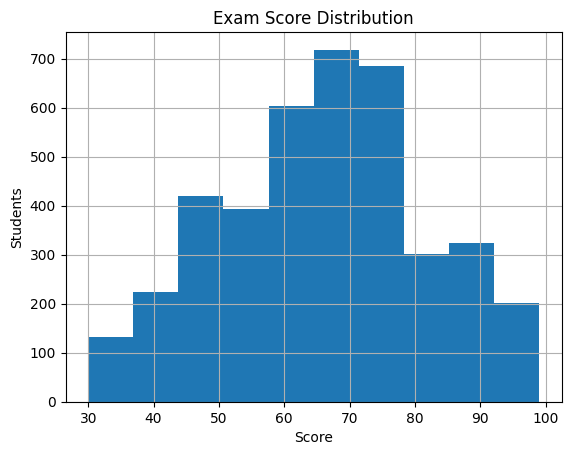

In [ ]:
# Histogram
df["exam_score"].hist()
plt.title("Exam Score Distribution")
plt.xlabel("Score")
plt.ylabel("Students")
plt.show()


In [ ]:
#The distribution of exam scores roughly follows a bell-shaped distribution, meaning most students have average scores while fewer students have very low or very high scores.
#This indicates the dataset is balanced and realistic for training a machine learning model.”

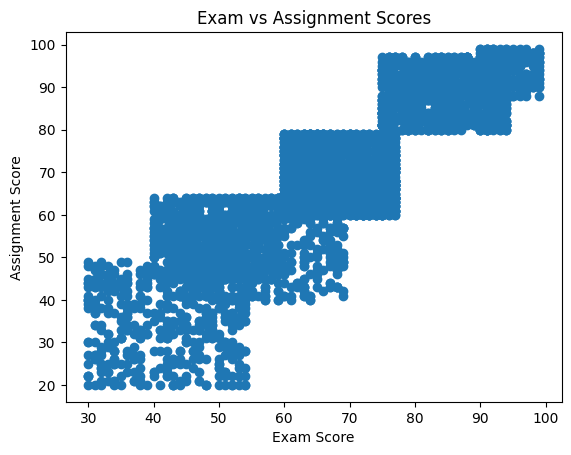

In [ ]:
plt.scatter(df["exam_score"],df["assignment_score"])
plt.xlabel("Exam Score")
plt.ylabel("Assignment Score")
plt.title("Exam vs Assignment Scores")
plt.show()

# Encode Labels

In [ ]:
# Basic features (for failure prediction)
basic_features = [
    "exam_score",
    "quiz_score",
    "assignment_score",
    "attendance_rate",
    "quiz_attempts",
    "study_time_hours",
    "login_frequency",
    "course_progress"
]

# Topic features (for topic recommendation)
topic_features = [
    "topic_variables",
    "topic_loops",
    "topic_functions",
    "topic_oop",
    "topic_recursion",
    "topic_datastructures"
]

# All features combined
all_features = basic_features + topic_features

# Encode topic labels
from sklearn.preprocessing import LabelEncoder

topic_encoder = LabelEncoder()
df["topic_encoded"] = topic_encoder.fit_transform(df["recommended_topic"])

strategy_encoder = LabelEncoder()
df["strategy_encoded"] = strategy_encoder.fit_transform(df["study_strategy"])

# Model 1: Failure Prediction

In [ ]:
#The first model predicts whether a student is at risk of failing the course.
X = df[basic_features]
y = df["failed"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
failure_model = RandomForestClassifier()
failure_model.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
# Cross Validation

cv_scores = cross_val_score(failure_model, X, y, cv=5)

print("Failure Model CV Scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

Failure Model CV Scores: [0.8125  0.85625 0.83375 0.84375 0.85   ]
Average CV Accuracy: 0.83925


In [ ]:
pred = failure_model.predict(X_test)

In [ ]:
accuracy_score(y_test,pred)

0.835

In [ ]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       546
           1       0.76      0.70      0.73       254

    accuracy                           0.83       800
   macro avg       0.81      0.80      0.80       800
weighted avg       0.83      0.83      0.83       800



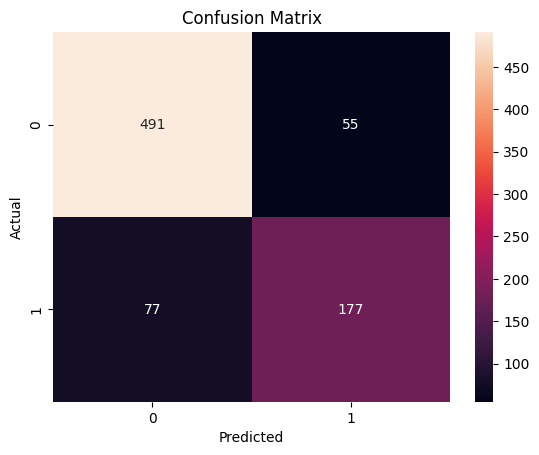

In [ ]:
cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

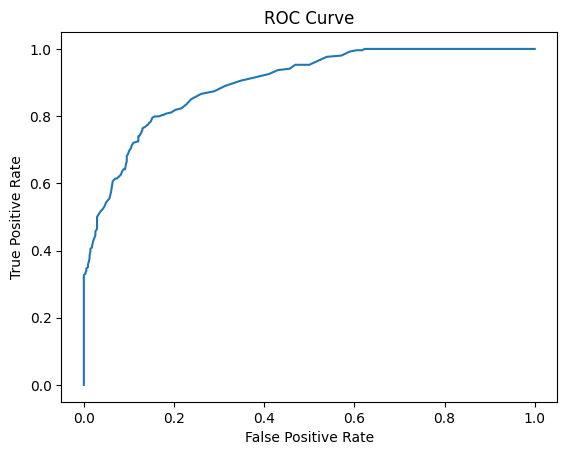

In [ ]:
probs = failure_model.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,probs)

plt.plot(fpr,tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

#Feature Importance

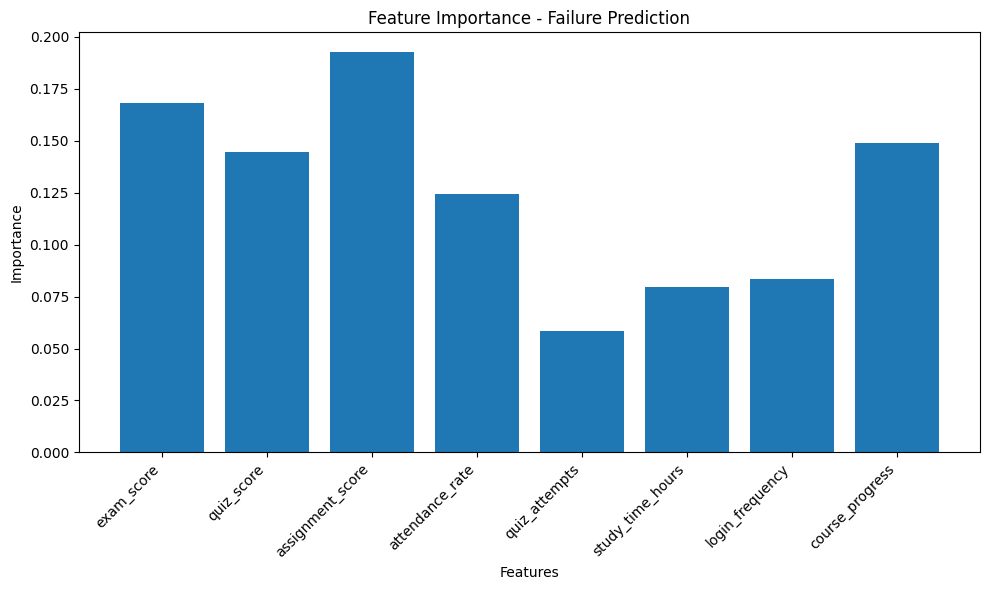

In [ ]:
importance = failure_model.feature_importances_
plt.figure(figsize=(10, 6))
plt.bar(basic_features, importance)
plt.title("Feature Importance - Failure Prediction")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Model 2:topic recommendation

In [ ]:
print("\n" + "="*60)
print("MODEL 2: TOPIC RECOMMENDATION")
print("="*60)

X = df[all_features]  # Use all features including topic scores
y = df["topic_encoded"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

topic_model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
topic_model.fit(X_train, y_train)



MODEL 2: TOPIC RECOMMENDATION


RandomForestClassifier(max_depth=20, n_estimators=200, random_state=42)

In [ ]:
# Cross Validation
cv_scores = cross_val_score(topic_model, X, y, cv=5)
print(f"\nTopic Model CV Scores: {cv_scores}")
print(f"Average CV Accuracy: {cv_scores.mean():.4f}")

pred = topic_model.predict(X_test)
print(f"\nTest Accuracy: {accuracy_score(y_test, pred):.4f}")


Topic Model CV Scores: [0.44375 0.41875 0.41875 0.46875 0.43   ]
Average CV Accuracy: 0.4360

Test Accuracy: 0.4363


In [ ]:
pred = topic_model.predict(X_test)

accuracy_score(y_test,pred)

0.43625

# Model 3:Study Strategy

In [ ]:
print("\n" + "="*60)
print("MODEL 3: STUDY STRATEGY RECOMMENDATION")
print("="*60)

X = df[all_features]
y = df["strategy_encoded"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

study_model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
study_model.fit(X_train, y_train)


MODEL 3: STUDY STRATEGY RECOMMENDATION


RandomForestClassifier(max_depth=20, n_estimators=200, random_state=42)

In [ ]:
# Cross Validation

cv_scores = cross_val_score(study_model, X, y, cv=5)
print(f"\nStudy Model CV Scores: {cv_scores}")
print(f"Average CV Accuracy: {cv_scores.mean():.4f}")

pred = study_model.predict(X_test)
print(f"\nTest Accuracy: {accuracy_score(y_test, pred):.4f}")


Study Model CV Scores: [0.9225  0.94625 0.93125 0.94375 0.93125]
Average CV Accuracy: 0.9350

Test Accuracy: 0.9363


In [ ]:
pred = study_model.predict(X_test)

accuracy_score(y_test,pred)

0.93625

# Test prediction

In [ ]:
 #Sample student: Struggling with Loops specifically
sample_basic = [[
    60,   # exam_score
    55,   # quiz_score
    62,   # assignment_score
    0.78, # attendance_rate
    4,    # quiz_attempts (many attempts - struggling)
    18,   # study_time_hours
    11,   # login_frequency
    0.68  # course_progress
]]

sample_all = [[
    60,   # exam_score
    55,   # quiz_score
    62,   # assignment_score
    0.78, # attendance_rate
    4,    # quiz_attempts
    18,   # study_time_hours
    11,   # login_frequency
    0.68, # course_progress
    85,   # topic_variables (good!)
    38,   # topic_loops (WEAK! - this is the problem)
    72,   # topic_functions
    58,   # topic_oop
    75,   # topic_recursion
    70    # topic_datastructures
]]

fail_prediction = failure_model.predict(sample_basic)[0]
topic_prediction = topic_model.predict(sample_all)[0]
strategy_prediction = study_model.predict(sample_all)[0]

print("\nStudent Profile:")
print(f"  Overall Performance: 60% (exam), 55% (quiz), 62% (assignment)")
print(f"  Engagement: 78% attendance, 11 logins/week")
print(f"  Study Behavior: 18 hours/week, 4 quiz attempts (struggling)")
print(f"\nTopic Scores:")
print(f"  Variables: 85% ✓")
print(f"  Loops: 38% ✗ (WEAKEST)")
print(f"  Functions: 72%")
print(f"  OOP: 58%")
print(f"  Recursion: 75%")
print(f"  Data Structures: 70%")

print(f"\n🤖 AI Predictions:")
print(f"  Failure Risk: {'⚠️  HIGH - Student at risk of failing' if fail_prediction == 1 else '✓ LOW - Student on track to pass'}")
print(f"  Recommended Topic: 📚 {topic_encoder.inverse_transform([topic_prediction])[0]}")
print(f"  Study Strategy: 💡 {strategy_encoder.inverse_transform([strategy_prediction])[0]}")



Student Profile:
  Overall Performance: 60% (exam), 55% (quiz), 62% (assignment)
  Engagement: 78% attendance, 11 logins/week
  Study Behavior: 18 hours/week, 4 quiz attempts (struggling)

Topic Scores:
  Variables: 85% ✓
  Loops: 38% ✗ (WEAKEST)
  Functions: 72%
  OOP: 58%
  Recursion: 75%
  Data Structures: 70%

🤖 AI Predictions:
  Failure Risk: ✓ LOW - Student on track to pass
  Recommended Topic: 📚 Loops
  Study Strategy: 💡 Practice Exercises


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# Save models

In [ ]:
# =============================================================================
# SAVE TRAINED MODELS
# =============================================================================

import joblib
import os

# Create a directory to store models (optional but cleaner)
os.makedirs("models", exist_ok=True)


# Save all models and encoders
joblib.dump(failure_model, "models/failure_model.pkl")
joblib.dump(topic_model, "models/topic_recommender.pkl")
joblib.dump(study_model, "models/study_strategy_model.pkl")
joblib.dump(topic_encoder, "models/topic_encoder.pkl")
joblib.dump(strategy_encoder, "models/strategy_encoder.pkl")

print("\n✅ Models saved successfully!")
print("\nSaved files:")
print("  📁 models/")
print("    ├── failure_model.pkl")
print("    ├── topic_recommender.pkl")
print("    ├── study_strategy_model.pkl")
print("    ├── topic_encoder.pkl")
print("    └── strategy_encoder.pkl")

# Also save feature names for future use
import json

feature_info = {
    "basic_features": [
        "exam_score",
        "quiz_score",
        "assignment_score",
        "attendance_rate",
        "quiz_attempts",
        "study_time_hours",
        "login_frequency",
        "course_progress"
    ],
    "topic_features": [
        "topic_variables",
        "topic_loops",
        "topic_functions",
        "topic_oop",
        "topic_recursion",
        "topic_datastructures"
    ],
    "all_features": [
        "exam_score",
        "quiz_score",
        "assignment_score",
        "attendance_rate",
        "quiz_attempts",
        "study_time_hours",
        "login_frequency",
        "course_progress",
        "topic_variables",
        "topic_loops",
        "topic_functions",
        "topic_oop",
        "topic_recursion",
        "topic_datastructures"
    ],
    "topics": ["Variables", "Loops", "Functions", "OOP", "Recursion", "Data_Structures"],
    "strategies": [
        "Review Lessons",
        "Extra Practice",
        "Practice Exercises",
        "Advanced Challenges",
        "Change Study Method",
        "Increase Study Time",
        "Interactive Exercises"
    ]
}

with open("models/feature_info.json", "w") as f:
    json.dump(feature_info, f, indent=2)

print("    ├── feature_info.json (feature metadata)")

# Verify models can be loaded
print("\n🔍 Verifying saved models can be loaded...")
try:
    test_failure = joblib.load("models/failure_model.pkl")
    test_topic = joblib.load("models/topic_recommender.pkl")
    test_strategy = joblib.load("models/study_strategy_model.pkl")
    test_topic_enc = joblib.load("models/topic_encoder.pkl")
    test_strategy_enc = joblib.load("models/strategy_encoder.pkl")
    print("✅ All models loaded successfully!")
except Exception as e:
    print(f"❌ Error loading models: {e}")

print("\n" + "="*60)
print("READY FOR DEPLOYMENT!")
print("="*60)
print("""
Next steps:
1. Copy the 'models/' folder to your backend project
2. Load these models in your backend API
3. Use them to make predictions for real students
4. See integration example below...
""")


✅ Models saved successfully!

Saved files:
  📁 models/
    ├── failure_model.pkl
    ├── topic_recommender.pkl
    ├── study_strategy_model.pkl
    ├── topic_encoder.pkl
    └── strategy_encoder.pkl
    ├── feature_info.json (feature metadata)

🔍 Verifying saved models can be loaded...
✅ All models loaded successfully!

READY FOR DEPLOYMENT!

Next steps:
1. Copy the 'models/' folder to your backend project
2. Load these models in your backend API
3. Use them to make predictions for real students
4. See integration example below...



In [ ]:
#Backend sends student data to the FastAPI AI service
#FastAPI loads the trained models (.pkl files)

In [ ]:
import shutil
shutil.make_archive("models", 'zip', "models")

'/content/models.zip'

# Conclusion

The trained models demonstrate how machine learning can be applied
to educational data to predict student performance and recommend
personalized study strategies.

Although the dataset is simulated, the system architecture can
be integrated with real student data in a school management system.